# Reconociendo imagenes

In [1]:
from dotenv import load_dotenv
from PIL import Image
from IPython.display import display

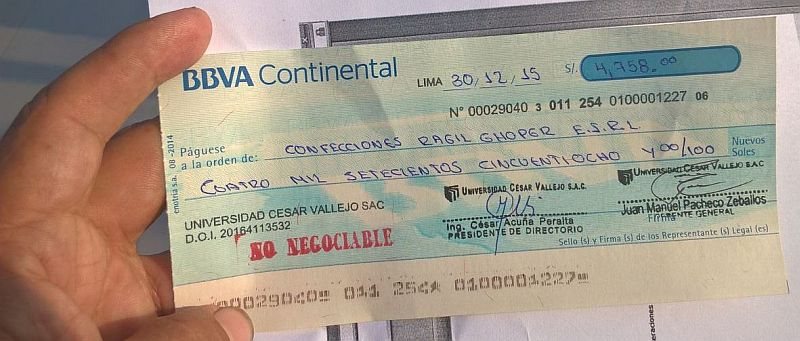

In [2]:
image_path = './images/cheque.jpg'

try:
    pil_image = Image.open(image_path)
    display(pil_image)
except FileNotFoundError:
    print(f"Error: The image file '{image_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

In [10]:
import ollama
from IPython.display import display, Markdown

prompt_cheque = "describe la imagen y luego como funcionario de negocio elabore un json donde se pueda estructurar una transaccion a partir del cheque"
with open(image_path, "rb") as f:
    image_bytes = f.read()

%time response = ollama.generate(model='llava', prompt=prompt_cheque, images=[image_path])
print()
display(Markdown(f"{response["response"]}"))
for item in response:
    print(item)


CPU times: total: 0 ns
Wall time: 18.9 s



 La imagen muestra una mano sosteniendo un recibo de caja con la inscripción "Banca Continental" y un cheque. El texto en el cheque incluye la fecha, el número de cuenta y el nombre del cliente, así como la cantidad pagada en cuestión de 1230 pesos.

Para estructurar una transacción a partir del cheque, aquí se muestra un ejemplo de cómo podría ser representado en formato JSON:

```json
{
  "Tipo": "Cheque",
  "Banco": "Continental",
  "Fecha": "30/12/2022",
  "Cuenta": "123456789-001",
  "Nombre del cliente": "JUAN LÓPEZ",
  "Dirección": "Av. Juan Carrasco, 50",
  "Valor nominal del cheque": 12345,
  "Cantidad pagada": 1230,
  "Referencia": "Pago de factura nº 123456",
  "Firma del cliente": "JUAN LÓPEZ"
}
```

En este ejemplo, se incluyen las características más importantes del cheque y la transacción, como el tipo de pago (Cheque), el nombre y número de cuenta bancario, el valor nominal del cheque y el valor pagado, y la firma del cliente. También podría incluir otras informaciones relevantes para la transacción, como una descripción detallada del servicio o producto adquirido con el cheque, la fecha de vencimiento del cheque, la fecha en que se recibe el cheque, la ubicación específica de la transacción (si es diferente al nombre y dirección del cliente), etc. 

('model', 'llava')
('created_at', '2026-08-11T11:57:12.3968372Z')
('done', True)
('done_reason', 'stop')
('total_duration', 18863528400)
('load_duration', 62848800)
('prompt_eval_count', 621)
('prompt_eval_duration', 263824000)
('eval_count', 461)
('eval_duration', 18408798000)
('response', ' La imagen muestra una mano sosteniendo un recibo de caja con la inscripción "Banca Continental" y un cheque. El texto en el cheque incluye la fecha, el número de cuenta y el nombre del cliente, así como la cantidad pagada en cuestión de 1230 pesos.\n\nPara estructurar una transacción a partir del cheque, aquí se muestra un ejemplo de cómo podría ser representado en formato JSON:\n\n```json\n{\n  "Tipo": "Cheque",\n  "Banco": "Continental",\n  "Fecha": "30/12/2022",\n  "Cuenta": "123456789-001",\n  "Nombre del cliente": "JUAN LÓPEZ",\n  "Dirección": "Av. Juan Carrasco, 50",\n  "Valor nominal del cheque": 12345,\n  "Cantidad pagada": 1230,\n  "Referencia": "Pago de factura nº 123456",\n  "Firma del 

In [ ]:
from openai import OpenAI
import base64
import os
from PIL import Image

# Inicializa el cliente de OpenAI (utiliza la variable de entorno OPENAI_API_KEY)
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

try:
    # 1. Define la ruta de tu imagen local (reemplaza con tu archivo real)
    image_path = './images/cheque.jpg'
    prompt_cheque = "describe la imagen y luego como funcionario de negocio elabore un json donde se pueda estructurar la data recopilada"

    if not os.path.exists(image_path):
        raise FileNotFoundError(f"No se encontró el archivo en: {image_path}")
    
    print("Codificando imagen...")
    with open(image_path, "rb") as f:
        imagen_base64 = base64.b64encode(f.read()).decode("utf-8")

    print("Enviando imagen a gpt-4o-mini para su análisis...")
    
    # 2. Invoca el modelo multimodal usando chat.completions
    respuesta = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "user",
                "content": [
                    # Mensaje de instrucción en texto
                    {
                        "type": "text", 
                        "text": prompt_cheque
                    },
                    # Objeto que contiene los datos de la imagen estructurados como Data URI
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{imagen_base64}"
                        }
                    }
                ]
            }
        ],
        max_tokens=500  # Límite máximo de tokens asignados para la descripción
    )

    # 3. Extrae e imprime la descripción devuelta por el modelo
    descripcion = respuesta.choices[0].message.content
    print("\n--- Descripción de la Imagen ---")
    print(descripcion)

except FileNotFoundError as fnf_error:
    print(f"Error de archivo: {fnf_error}")
except Exception as e:
    print(f"Ocurrió un error inesperado al procesar la API: {e}")


Codificando imagen...
Enviando imagen a gpt-4o para su análisis...

--- Descripción de la Imagen ---
La imagen muestra un cheque del banco BBVA Continental. El cheque tiene una fecha escrita, que es el 30 de diciembre de 2015. Está dirigido a "Confecciones Ragil Ghorre E.I.R.L." y el monto del cheque es de 4,758.00 soles. También se observa la marca "NO NEGOCIABLE" en el cheque, junto con la información de la universidad César Vallejo y otros detalles como el firma del presidente del directorio.

A continuación, se presenta un ejemplo de cómo estructurar la información en un formato JSON:

```json
{
  "cheque": {
    "banco": "BBVA Continental",
    "fecha": "30/12/2015",
    "beneficiario": "Confecciones Ragil Ghorre E.I.R.L.",
    "monto": 4758.00,
    "moneda": "Nuevos Soles",
    "estado": "NO NEGOCIABLE",
    "universidad": {
      "nombre": "Universidad César Vallejo",
      "doy": "201614113532"
    },
    "firmas": {
      "presidente_directorio": "Juan Manuel Pacheco Zeballos"

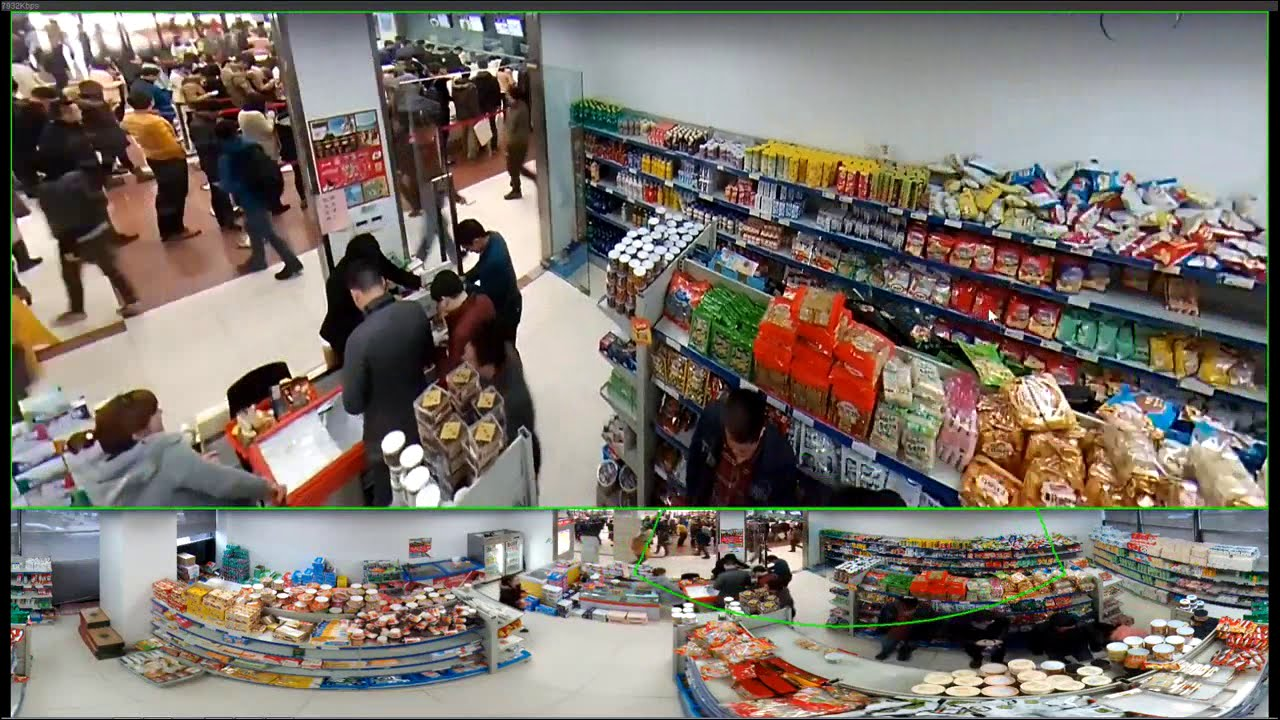

In [30]:
image_path = './images/supermercado.jpg'
try:
    pil_image = Image.open(image_path)
    display(pil_image)
except FileNotFoundError:
    print(f"Error: The image file '{image_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

In [32]:
from openai import OpenAI
import base64
import os
from IPython.display import display, Markdown
from PIL import Image

# Inicializa el cliente de OpenAI (utiliza la variable de entorno OPENAI_API_KEY)
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

try:
    # 1. Define la ruta de tu imagen local (reemplaza con tu archivo real)
    image_path = './images/supermercado.jpg'
    prompt_cheque = "describe la imagen y gana el mayor detalle posible de cada elemento, persona y posibles interacciones entre ellos, " \
    "luego como como personal de seguridad elabore un json donde se pueda estructurar la data recopilada y posibles riesgos de seguridad" \
    "indicando donde se encuentran los elementos de riesgo y posibles acciones a tomar para mitigarlos"

    if not os.path.exists(image_path):
        raise FileNotFoundError(f"No se encontró el archivo en: {image_path}")
    
    print("Codificando imagen...")
    with open(image_path, "rb") as f:
        imagen_base64 = base64.b64encode(f.read()).decode("utf-8")

    print("Enviando imagen a gpt-4o para su análisis...")
    
    # 2. Invoca el modelo multimodal usando chat.completions
    respuesta = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {
                "role": "user",
                "content": [
                    # Mensaje de instrucción en texto
                    {
                        "type": "text", 
                        "text": prompt_cheque
                    },
                    # Objeto que contiene los datos de la imagen estructurados como Data URI
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{imagen_base64}"
                        }
                    }
                ]
            }
        ],
        max_tokens=500  # Límite máximo de tokens asignados para la descripción
    )

    # 3. Extrae e imprime la descripción devuelta por el modelo
    descripcion = respuesta.choices[0].message.content
    print("\n--- Descripción de la Imagen ---")
    display(Markdown(f"{descripcion}"))

except FileNotFoundError as fnf_error:
    print(f"Error de archivo: {fnf_error}")
except Exception as e:
    print(f"Ocurrió un error inesperado al procesar la API: {e}")

Codificando imagen...
Enviando imagen a gpt-4o para su análisis...

--- Descripción de la Imagen ---


**Descripción de la imagen:**

La imagen muestra una perspectiva de varias cámaras de seguridad en un pequeño supermercado o tienda de conveniencia. Hay estantes llenos de productos como alimentos envasados, bebidas y snacks. Hay varias personas visibles a lo largo de la tienda que están realizando sus compras cerca del mostrador de la caja.

1. **Personas:**
   - Un grupo de personas está reunido cerca del mostrador de pago, probablemente haciendo fila para pagar.
   - Algunas personas están mirando los productos en los estantes.
   
2. **Estantes y Productos:**
   - Los estantes están bien surtidos con una variedad de productos, como aperitivos, latas, y otras mercancías.
   - En el frente del mostrador hay productos pequeños como puede haber bebidas en frío o dulces.

3. **Área del mostrador:**
   - Hay al menos una persona detrás del mostrador, probablemente un cajero.

4. **Distribución:**
   - La tienda está organizada de manera que facilita la circulación, pero también se observa que hay momentos en que puede parecer congestionada.

**Posibles Interacciones:**
- Personas interactuando entre ellas al realizar las compras.
- Interacciones entre clientes y el cajero al momento de pagar.

**Posibles Riesgos de Seguridad:**

1. **Riesgo de Robo:**
   - La congestión en ciertos puntos puede facilitar el robo en caso de descuido.
   - Mitigación: Uso de cámaras de seguridad adicionales y formación del personal para estar atentos a comportamientos sospechosos.

2. **Riesgo de Atascos:**
   - La acumulación de personas en cierto punto del mostrador puede generar atascos, lo cual en caso de emergencia podría ser problemático.
   - Mitigación: Mejorar la gestión de filas y abrir más cajas cuando sea necesario.

3. **Riesgo de Resbalones:**
   - Productos en el suelo o estructuras podrían causar accidentes.
   - Mitigación: Mantener el área limpia y libre de obstáculos, señalización adecuada de áreas resbaladizas.

**Estructuración en formato JSON:**

```json
{
  "people": {
    "groupNearCounter": true,
    "customers": [
      {"position": "near the counter", "action": "waiting/payment"},
      {"position": "browsing shelves", "action": "shopping"}
    ]


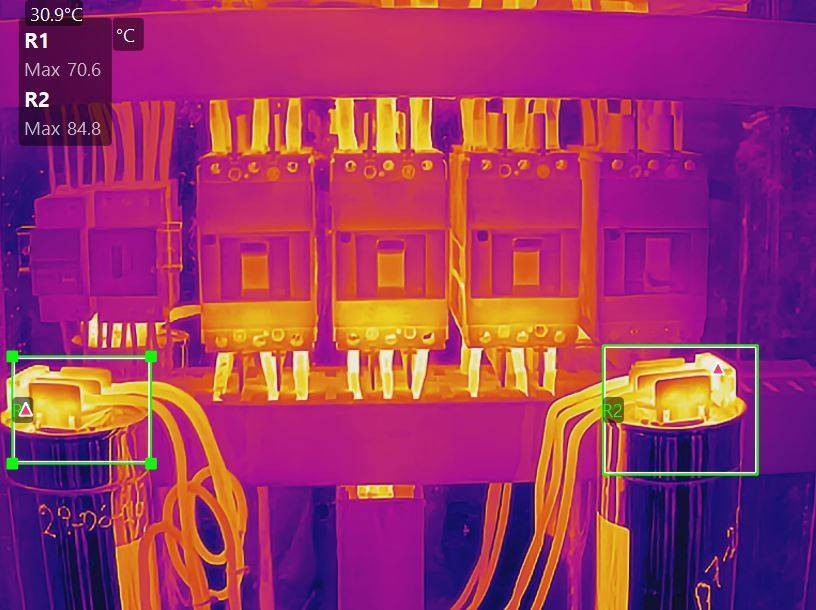

In [33]:
image_path = './images/condensadores.jpg'
try:
    pil_image = Image.open(image_path)
    display(pil_image)
except FileNotFoundError:
    print(f"Error: The image file '{image_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

In [36]:
from openai import OpenAI
import base64
import os
from IPython.display import display, Markdown
from PIL import Image

# Inicializa el cliente de OpenAI (utiliza la variable de entorno OPENAI_API_KEY)
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

try:
    # 1. Define la ruta de tu imagen local (reemplaza con tu archivo real)
    image_path = './images/condensadores.jpg'
    prompt_cheque = "describe la imagen de condensadores y gana el mayor detalle posible de cada elemento y posibles interacciones entre ellos, " \
    "luego como como personal de seguridad de data center elabora un json donde se pueda estructurar la data recopilada y posibles riesgos" \
    "indicando donde se encuentran los elementos de riesgo y posibles acciones a tomar para mitigarlos"

    if not os.path.exists(image_path):
        raise FileNotFoundError(f"No se encontró el archivo en: {image_path}")
    
    print("Codificando imagen...")
    with open(image_path, "rb") as f:
        imagen_base64 = base64.b64encode(f.read()).decode("utf-8")

    print("Enviando imagen a gpt-4o para su análisis...")
    
    # 2. Invoca el modelo multimodal usando chat.completions
    respuesta = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {
                "role": "user",
                "content": [
                    # Mensaje de instrucción en texto
                    {
                        "type": "text", 
                        "text": prompt_cheque
                    },
                    # Objeto que contiene los datos de la imagen estructurados como Data URI
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{imagen_base64}"
                        }
                    }
                ]
            }
        ],
        max_tokens=500  # Límite máximo de tokens asignados para la descripción
    )

    # 3. Extrae e imprime la descripción devuelta por el modelo
    descripcion = respuesta.choices[0].message.content
    print("\n--- Descripción de la Imagen ---")
    display(Markdown(f"{descripcion}"))

except FileNotFoundError as fnf_error:
    print(f"Error de archivo: {fnf_error}")
except Exception as e:
    print(f"Ocurrió un error inesperado al procesar la API: {e}")

Codificando imagen...
Enviando imagen a gpt-4o para su análisis...

--- Descripción de la Imagen ---


La imagen es una termografía de lo que parecen ser componentes eléctricos, específicamente condensadores y sus conexiones en un tablero o cuadro de circuitos.

### Detalles de los Elementos:

1. **Condensadores:**
   - Hay dos condensadores visibles, marcados como R1 y R2.
   - La temperatura máxima de R1 es 70.6°C.
   - La temperatura máxima de R2 es 84.8°C.
   - Los condensadores están ubicados en la parte inferior de la imagen.

2. **Interruptores/Circuitos:**
   - Se observan múltiples interruptores o dispositivos de control, visibles en la parte superior central de la imagen.
   - Estos elementos tienen rangos de temperatura variada; la mayor concentración de calor se observa en los terminales superiores.

3. **Cables:**
   - Varios cables están conectados a los condensadores y los interruptores.
   - Los cables parecen estar dentro de un rango térmico seguro, pero el monitoreo constante es necesario.

4. **Temperatura Ambiente:**
   - La temperatura ambiente es de 30.9°C, lo cual es notablemente más bajo que la temperatura de los componentes.

### Interacciones:
- La temperatura elevada en R2 es una preocupación mayor debido a su proximidad al resto de los componentes.
- Los puntos calientes en los interruptores y conexiones indican una carga eléctrica significativa o resistencia.

### JSON Estructurado para Datos de Seguridad:

```json
{
  "Condensadores": [
    {
      "Nombre": "R1",
      "MaximoTemperatura": 70.6,
      "Estado": "Critico",
      "Acciones": [
        "Monitorear constantemente",
        "Inspeccionar conexiones y disipar calor"
      ]
    },
    {
      "Nombre": "R2",
      "MaximoTemperatura": 84.8,
      "Estado": "Critico",
      "Acciones": [
        "Inspeccionar inmediatamente",
        "Considerar mejorar el sistema de enfriamiento"
      ]
    }
  ],
  "Circuitos/Interruptores": [
    {
      "MaximoTemperatura": "Variable",
      "Estado": "Monitorear",
      "Acciones": [
        "Revisar conexiones de alta resistencia",
        "Asegurar mantenimiento regular"
      ]
    }
  ],
  "Cables": {
    "Estado

# Generando Imagenes

In [27]:
import base64
import os
from io import BytesIO
from openai import OpenAI
from PIL import Image

# Inicializa el cliente de OpenAI (carga automáticamente la variable OPENAI_API_KEY del entorno)
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))
image_prompt = """
Fotografía editorial de cuerpo completo de una modelo usando una chaqueta inflable tipo plumón con 
forma escultórica de cabeza de oso. La chaqueta incluye detalles de pelaje texturizado y elementos metálicos,
decorada con ornamentos inspirados en un tocado tradicional de dragón chino.
Fondo limpio de estudio, iluminación de alta moda, enfoque nítido, sombras dramáticas.
Estética de revista tipo Vogue —ar 16:9 —style raw —v 6.0
"""

try:
    print("Enviando solicitud a gpt-image-1...")
    
    # Invoca el modelo gpt-image-1
    response = client.images.generate(
        model="gpt-image-1",
        prompt=image_prompt,
        n=1,
        size="1024x1024",       # Opciones: "1024x1024", "1024x1536", "1536x1024"
        quality="high",         # Opciones: "low", "medium", "high"
        # response_format="b64_json" (gpt-image-1 devuelve por defecto la imagen en base64, por lo que no es necesario especificarlo explícitamente)
    )

    # Extrae la cadena base64 de la respuesta del API
    b64_data = response.data[0].b64_json
    
    # Decodifica la cadena base64 para convertirla de nuevo en datos binarios de imagen
    image_bytes = base64.b64decode(b64_data)
    
    # Abre los datos de la imagen y la guarda en el disco local
    image = Image.open(BytesIO(image_bytes))
    output_filename = "./images/modelo_futurista.png"
    image.save(output_filename)
    
    print(f"¡Éxito! Imagen guardada localmente como: {output_filename}")
    
    # Opcional: Muestra el consumo de tokens (característica única de los modelos gpt-image)
    if hasattr(response, 'usage') and response.usage:
        print(f"Consumo de tokens: {response.usage.total_tokens} tokens en total.")

except Exception as e:
    print(f"Ocurrió un error: {e}")


Enviando solicitud a gpt-image-1...
¡Éxito! Imagen guardada localmente como: ./images/modelo_futurista.png
Consumo de tokens: 4270 tokens en total.


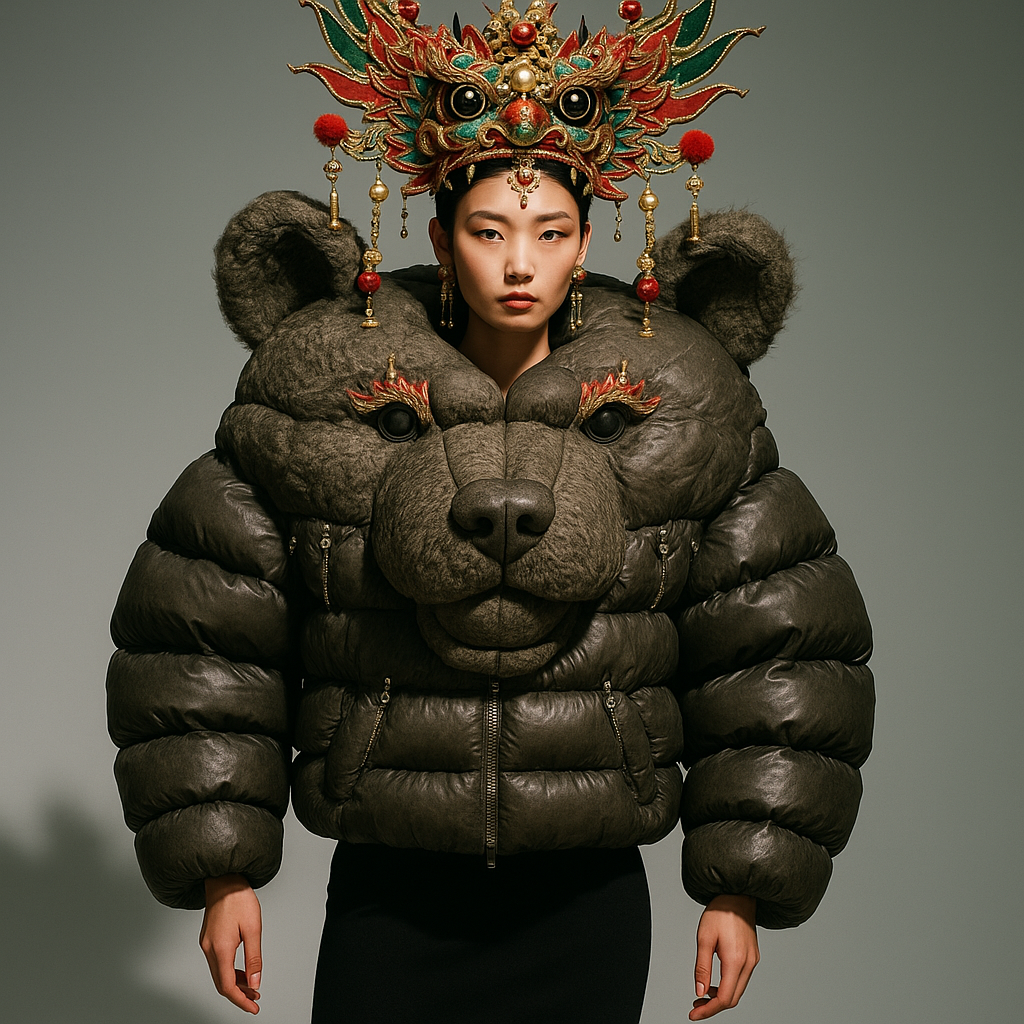

In [37]:
image_path = "./images/modelo_futurista.png"
try:
    pil_image = Image.open(image_path)
    display(pil_image)
except FileNotFoundError:
    print(f"Error: The image file '{image_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
import os
import time
from openai import OpenAI

# Inicializa el cliente de OpenAI
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

def generar_y_descargar_video():
    try:
        print("1. Enviando solicitud de generación de video a Sora...")
        
        # Iniciar la tarea de creación de video
        video_job = client.videos.create(
            model="sora-2",                # Opciones: "sora-2" o "sora-2-pro"
            prompt="A majestic cinematic drone shot of a snow-covered mountain range at sunrise, high definition, 4k",
            seconds=4,                     # Duración aceptada: 4, 8, o 12 segundos
            size="1280x720"                # Resoluciones: "1280x720" o "720x1280"
        )
        
        video_id = video_job.id
        print(f"Tarea creada exitosamente. ID del Video: {video_id}")
        
        # 2. Bucle de consulta (Polling) para verificar el estado
        print("\n2. Esperando a que el video termine de renderizarse...")
        while True:
            # Consultar el estado actual usando el ID
            status_check = client.videos.retrieve(video_id)
            estado = status_check.status
            
            # Muestra el porcentaje estimado si está disponible en la respuesta
            progreso = getattr(status_check, 'progress', 0)
            print(f"Estado actual: {estado} (Progreso: {progreso}%)")
            
            if estado == "completed":
                print("¡El video se ha renderizado con éxito!")
                break
            elif estado == "failed":
                # Si falla, se extrae el mensaje de error estructurado del API
                error_msg = getattr(status_check, 'error', 'Error desconocido')
                raise Exception(f"La generación de video falló. Detalle: {error_msg}")
            
            # Esperar 15 segundos antes de la siguiente consulta
            time.sleep(15)
            
        # 3. Descargar el archivo binario usando el método oficial del SDK
        print("\n3. Descargando el archivo de video final...")
        nombre_archivo = "./video/montana_amanecer.mp4"
        
        # Invocación al endpoint correcto de descarga nativa
        video_content = client.videos.download_content(video_id=video_id)
        
        # Guarda el flujo binario directamente en un archivo local
        video_content.write_to_file(nombre_archivo)
        print(f"¡Éxito! El video se ha guardado localmente como '{nombre_archivo}'.")

    except Exception as e:
        print(f"\nOcurrió un error en el proceso: {e}")

if __name__ == "__main__":
    generar_y_descargar_video()


1. Enviando solicitud de generación de video a Sora...
Tarea creada exitosamente. ID del Video: video_6a7b1c2451dc8193b19a533f1dfe1d340f833c3b09b884c7

2. Esperando a que el video termine de renderizarse...
Estado actual: in_progress (Progreso: 0%)
Estado actual: in_progress (Progreso: 0%)
Estado actual: in_progress (Progreso: 0%)
Estado actual: in_progress (Progreso: 99%)
Estado actual: completed (Progreso: 100%)
¡El video se ha renderizado con éxito!

3. Descargando el archivo de video final...
¡Éxito! El video se ha guardado localmente como 'montana_amanecer.mp4'.


In [ ]:
import sys
import time
from openai import OpenAI

openai = OpenAI()

video = openai.videos.create(
    model="sora-2",
    prompt="""YouTuber, camiseta negra, en un estudio profesional, sentado en su escritorio, hablando directamente a un micrófono Shure SM7B con brazo articulado.
    Dice con una sonrisa irónica: «Espera... ¿me acaba de generar una IA para enseñarte sobre IA? Qué meta...». Fondo oscuro con una suave luz LED azul.
    Iluminación profesional con luz principal y luz de contorno. Grabado con Sony FX6, profundidad de campo cinematográfica, enfoque nítido, formato vertical 9:16.""",
    size="720x1280",
    seconds="4",
)

print("Video generation started:", video)


Video generation started: Video(id='video_6a7b19a9f1f08191bdaaf55863c79fd4012386c59618619e', completed_at=None, created_at=1786452394, error=None, expires_at=None, model='sora-2', object='video', progress=0, prompt='YouTuber, camiseta negra, en un estudio profesional, sentado en su escritorio, hablando directamente a un micrófono Shure SM7B con brazo articulado.\n    Dice con una sonrisa irónica: «Espera... ¿me acaba de generar una IA para enseñarte sobre IA? Qué meta...». Fondo oscuro con una suave luz LED azul.\n    Iluminación profesional con luz principal y luz de contorno. Grabado con Sony FX6, profundidad de campo cinematográfica, enfoque nítido, formato vertical 9:16.', remixed_from_video_id=None, seconds='4', size='720x1280', status='queued', edited_from_video_id=None, extended_from_video_id=None)


In [ ]:
video_id = video.id
video_id = 'video_6a7b19a9f1f08191bdaaf55863c79fd4012386c59618619e'
# 3. Descargar el archivo binario usando el método oficial del SDK
print("\n3. Descargando el archivo de video final...")
nombre_archivo = "./video/youtuber.mp4"

# Invocación al endpoint correcto de descarga nativa
video_content = client.videos.download_content(video_id=video_id)

# Guarda el flujo binario directamente en un archivo local
video_content.write_to_file(nombre_archivo)
print(f"¡Éxito! El video se ha guardado localmente como '{nombre_archivo}'.")


3. Descargando el archivo de video final...
¡Éxito! El video se ha guardado localmente como 'montana_amanecer.mp4'.
